In [1]:
# Cell 0 — Setup
!pip -q install scipy matplotlib seaborn pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, multivariate_normal, f_oneway, linregress

sns.set(style="whitegrid")
np.set_printoptions(suppress=True, precision=3)

print("✅ Ready — SciPy/NumPy/Matplotlib loaded")


✅ Ready — SciPy/NumPy/Matplotlib loaded


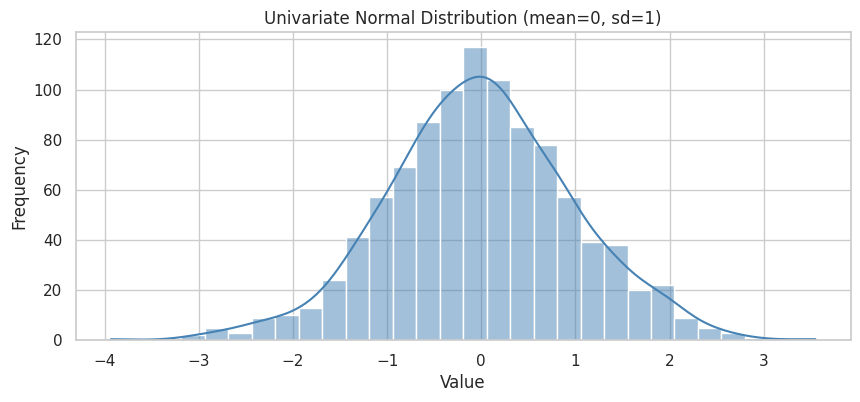

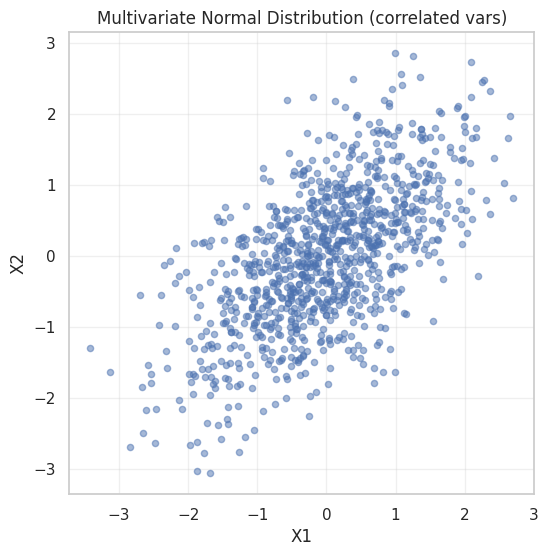

✅ Difference: Univariate ~ 1D bell curve; Multivariate ~ 2D cloud shaped by covariance.


In [2]:
# Cell 1 — Univariate & Multivariate Normal Distribution

# Univariate normal
uni = norm.rvs(size=1000, loc=0, scale=1)

plt.figure(figsize=(10,4))
sns.histplot(uni, bins=30, kde=True, color="steelblue")
plt.title("Univariate Normal Distribution (mean=0, sd=1)")
plt.xlabel("Value"); plt.ylabel("Frequency")
plt.show()

# Multivariate normal
mean = [0,0]
cov = [[1,0.6],[0.6,1]]  # correlated vars
multi = multivariate_normal.rvs(mean=mean, cov=cov, size=1000)

plt.figure(figsize=(6,6))
plt.scatter(multi[:,0], multi[:,1], alpha=0.5, s=20)
plt.title("Multivariate Normal Distribution (correlated vars)")
plt.xlabel("X1"); plt.ylabel("X2")
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Difference: Univariate ~ 1D bell curve; Multivariate ~ 2D cloud shaped by covariance.")


In [3]:
# Cell 2 — Advanced probability distribution (theory)

print("""
📊 Example: Poisson distribution
--------------------------------
We can model the number of customers arriving at a shop per hour with a Poisson distribution.

- Assumptions: arrivals are independent, occur with constant average rate λ.
- Implication: probability of k arrivals in an interval is
  P(k) = (λ^k * e^-λ) / k!
- Use case: staffing optimization — knowing λ helps decide how many staff are needed.

Similarly, exponential distribution could model waiting time until next earthquake.
""")



📊 Example: Poisson distribution
--------------------------------
We can model the number of customers arriving at a shop per hour with a Poisson distribution.

- Assumptions: arrivals are independent, occur with constant average rate λ.
- Implication: probability of k arrivals in an interval is
  P(k) = (λ^k * e^-λ) / k!
- Use case: staffing optimization — knowing λ helps decide how many staff are needed.

Similarly, exponential distribution could model waiting time until next earthquake.



In [4]:
# Cell 3 — ANOVA with sales across 3 regions

np.random.seed(0)
region1 = np.random.normal(20000, 3000, 30)
region2 = np.random.normal(22000, 3500, 30)
region3 = np.random.normal(25000, 5000, 30)

sales_data = pd.DataFrame({
    "Region 1": region1,
    "Region 2": region2,
    "Region 3": region3
})
display(sales_data.head())

# ANOVA test
F, p = f_oneway(region1, region2, region3)
print(f"F-statistic: {F:.3f} | p-value: {p:.3e}")

if p < 0.05:
    print("➡️ Reject H0: at least one region mean differs significantly.")
else:
    print("➡️ Fail to reject H0: no significant difference between regions.")


,Region 1,Region 2,Region 3
0,25292.157038,22542.315990,21637.697761
1,21200.471625,23323.568819,23202.234192
2,22936.213952,18892.749883,20934.268590
3,26722.679598,15067.212361,16368.586988
4,25602.673970,20782.307477,25887.130711


F-statistic: 6.862 | p-value: 1.709e-03
➡️ Reject H0: at least one region mean differs significantly.


,Hours Studied,Test Score
0,27.440675,56.950190
1,35.759468,98.406936
2,30.138169,80.002046
3,27.244159,52.747961
4,21.182740,67.839372


Slope: 2.487
Intercept: 2.222
R-squared: 0.928
Predicted score (90h): 226.09


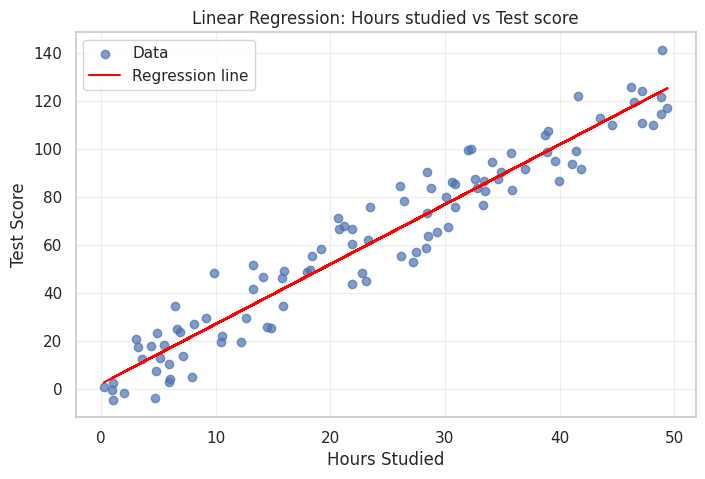


Interpretation:
- Slope ≈ 2.5 → each additional hour studied increases test score by ~2.5 points (on avg).
- Intercept → expected score at 0h studied.
- R² shows proportion of variance explained by hours studied.



In [5]:
# Cell 4 — Linear regression on hours studied vs test scores

np.random.seed(0)
X = np.random.rand(100) * 50
Y = 2.5*X + np.random.randn(100)*10

df_lr = pd.DataFrame({"Hours Studied": X, "Test Score": Y})
display(df_lr.head())

slope, intercept, r_value, p_value, std_err = linregress(X, Y)

print(f"Slope: {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R-squared: {r_value**2:.3f}")

# Prediction for 90 hours studied
pred_90 = slope*90 + intercept
print(f"Predicted score (90h): {pred_90:.2f}")

# Visualization
plt.figure(figsize=(8,5))
plt.scatter(X, Y, label="Data", alpha=0.7)
plt.plot(X, slope*X+intercept, color="red", label="Regression line")
plt.title("Linear Regression: Hours studied vs Test score")
plt.xlabel("Hours Studied"); plt.ylabel("Test Score")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print("""
Interpretation:
- Slope ≈ 2.5 → each additional hour studied increases test score by ~2.5 points (on avg).
- Intercept → expected score at 0h studied.
- R² shows proportion of variance explained by hours studied.
""")
